In [118]:
import numpy as np

In [119]:
import pandas as pd

In [120]:
import matplotlib.pyplot as plt

In [121]:
import yfinance as yf

In [122]:
rets = yf.download(tickers='SPY',
                   interval='1mo',
                   start='1993-01-29')["Close"]


[*********************100%***********************]  1 of 1 completed


In [123]:
type(rets)

pandas.DataFrame

In [124]:
rets

Ticker,SPY
Date,
1993-01-01,24.175390
1993-02-01,24.433290
1993-03-01,24.863176
1993-04-01,24.341404
1993-05-01,24.997858
...,...
2026-01-01,690.085327
2026-02-01,684.121643
2026-03-01,648.568787


In [125]:
rets = yf.download(tickers=['SPY', 'BND'],
                   interval='1mo',
                   start='1993-1-29')["Close"]

[*********************100%***********************]  2 of 2 completed


In [126]:
type(rets)

pandas.DataFrame

In [127]:
rets

Ticker,BND,SPY
Date,,
1993-01-01,NaN,24.175390
1993-02-01,NaN,24.433306
1993-03-01,NaN,24.863163
1993-04-01,NaN,24.341381
1993-05-01,NaN,24.997860
...,...,...
2026-01-01,73.268166,690.085327
2026-02-01,74.195969,684.121643
2026-03-01,72.926491,648.568787


In [128]:
rets.dropna(inplace=True)
rets

Ticker,BND,SPY
Date,,
2007-04-01,41.498085,104.388702
2007-05-01,41.102287,107.929596
2007-06-01,40.901760,105.895142
2007-07-01,41.292027,103.021706
2007-08-01,41.865395,104.343727
...,...,...
2026-01-01,73.268166,690.085327
2026-02-01,74.195969,684.121643
2026-03-01,72.926491,648.568787


<Axes: xlabel='Date'>

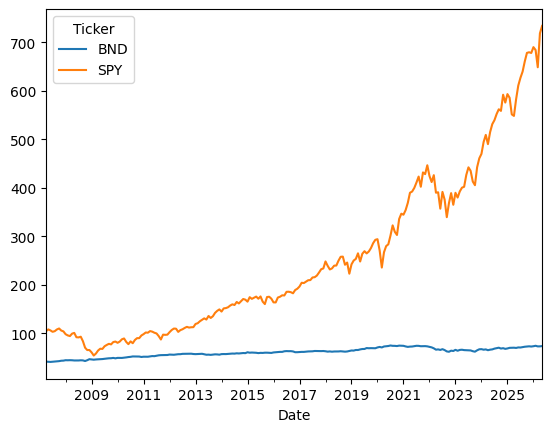

In [129]:
rets.plot()

In [130]:
rets = rets.pct_change().dropna()

<Axes: xlabel='Date'>

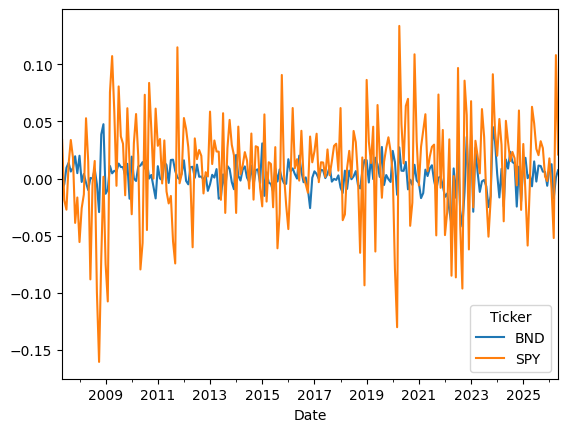

In [131]:
rets.plot()

In [132]:
compound_returns = (rets + 1).prod() - 1

In [133]:
(compound_returns * 100).round(2).astype('str') + '%'

Ticker
BND     77.24%
SPY    602.98%
dtype: str

In [134]:
rets.head(), \
rets.tail(), \
rets.size, \
rets.shape

(Ticker           BND       SPY
 Date                          
 2007-05-01 -0.009538  0.033920
 2007-06-01 -0.004879 -0.018850
 2007-07-01  0.009542 -0.027135
 2007-08-01  0.013886  0.012832
 2007-09-01  0.006212  0.033810,
 Ticker           BND       SPY
 Date                          
 2026-01-01  0.008730  0.017736
 2026-02-01  0.012663 -0.008642
 2026-03-01 -0.017110 -0.051969
 2026-04-01  0.001136  0.108071
 2026-05-01  0.007406  0.021109,
 458,
 (229, 2))

In [135]:
rets.index, \
rets.columns, \
rets['SPY'], \
rets[['SPY']]

(DatetimeIndex(['2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01',
                '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01',
                '2008-01-01', '2008-02-01',
                ...
                '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-01',
                '2025-12-01', '2026-01-01', '2026-02-01', '2026-03-01',
                '2026-04-01', '2026-05-01'],
               dtype='datetime64[s]', name='Date', length=229, freq=None),
 Index(['BND', 'SPY'], dtype='str', name='Ticker'),
 Date
 2007-05-01    0.033920
 2007-06-01   -0.018850
 2007-07-01   -0.027135
 2007-08-01    0.012832
 2007-09-01    0.033810
                 ...   
 2026-01-01    0.017736
 2026-02-01   -0.008642
 2026-03-01   -0.051969
 2026-04-01    0.108071
 2026-05-01    0.021109
 Name: SPY, Length: 229, dtype: float64,
 Ticker           SPY
 Date                
 2007-05-01  0.033920
 2007-06-01 -0.018850
 2007-07-01 -0.027135
 2007-08-01  0.012832
 2007-09-01  0.033810
 ...       

In [136]:
rets.loc['2009-02'], \
rets.iloc[20]

(Ticker           BND       SPY
 Date                          
 2009-02-01 -0.009569 -0.107449,
 Ticker
 BND   -0.013230
 SPY   -0.074663
 Name: 2009-01-01 00:00:00, dtype: float64)

In [137]:
rets.loc['2009-02': '2009-05'], \
rets.iloc[20:24]

(Ticker           BND       SPY
 Date                          
 2009-02-01 -0.009569 -0.107449
 2009-03-01  0.011090  0.075612
 2009-04-01  0.004644  0.107214
 2009-05-01  0.006865  0.058454,
 Ticker           BND       SPY
 Date                          
 2009-01-01 -0.013230 -0.074663
 2009-02-01 -0.009569 -0.107449
 2009-03-01  0.011090  0.075612
 2009-04-01  0.004644  0.107214)

In [138]:
rets.std()

Ticker
BND    0.013416
SPY    0.045526
dtype: float64

In [139]:
n_periods = rets.shape[0]

In [140]:
compounded_growth = (1+rets).prod()

In [141]:
monthly_ret = compounded_growth**(1/n_periods) - 1

In [142]:
(monthly_ret + 1)**12 - 1

Ticker
BND    0.030445
SPY    0.107596
dtype: float64

In [143]:
def annualize_rets(r, periods_per_year=12):
    compounded_growth = (1+r).prod()
    n_periods = r.shape[0]
    return compounded_growth**(periods_per_year / n_periods) - 1

In [144]:
annualize_rets(rets)

Ticker
BND    0.030445
SPY    0.107596
dtype: float64

In [145]:
def annualize_vol(r, periods_per_year=12):
    return r.std() * (periods_per_year**0.5)

In [146]:
annualize_vol(rets)

Ticker
BND    0.046476
SPY    0.157708
dtype: float64

In [147]:
# Raq Sharpe Ratio
annualize_rets(rets) / annualize_vol(rets)

Ticker
BND    0.655066
SPY    0.682246
dtype: float64

In [148]:
wealth_index = (1+rets).cumprod()

<Axes: xlabel='Date'>

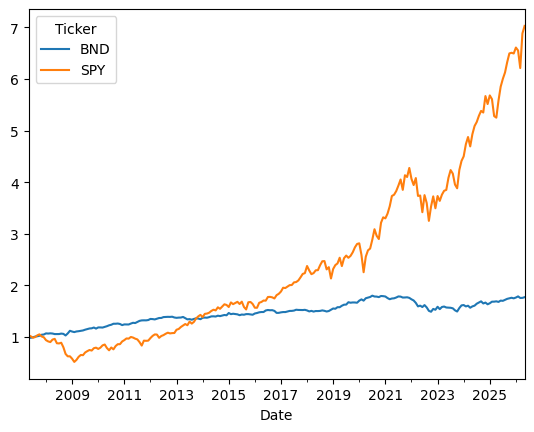

In [149]:
wealth_index.plot()

In [150]:
rets = yf.download(tickers='SPY',
                   start='1993-01-29',
                   interval='1mo',
                   auto_adjust=True)["Close"].squeeze().pct_change().dropna()
rets

[*********************100%***********************]  1 of 1 completed


Date
1993-02-01    0.010669
1993-03-01    0.017592
1993-04-01   -0.020985
1993-05-01    0.026970
1993-06-01   -0.003455
                ...   
2026-01-01    0.017736
2026-02-01   -0.008642
2026-03-01   -0.051969
2026-04-01    0.108071
2026-05-01    0.021109
Name: SPY, Length: 400, dtype: float64

Text(2011-02-01 00:00:00, -0.609417904783917, 'Max Drawdown: -50.78%')

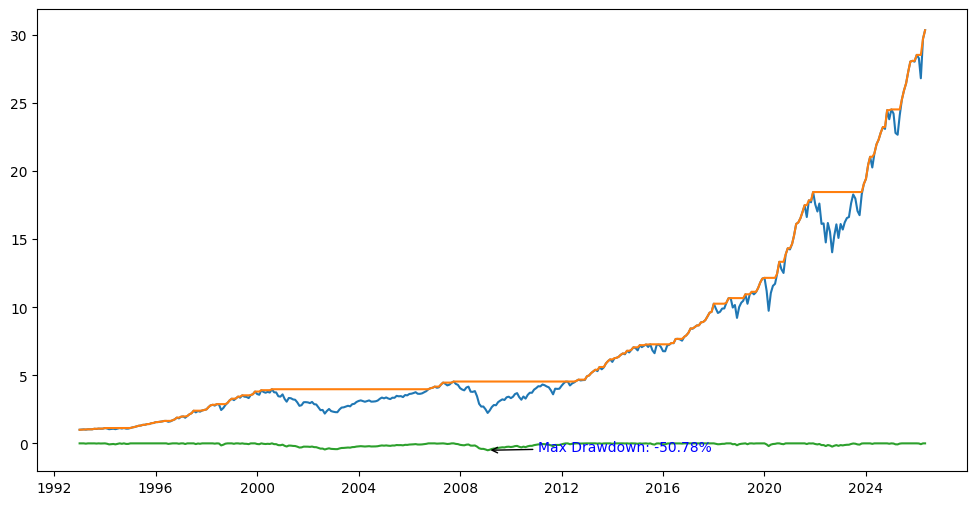

In [151]:

wealth_index = (1+rets).cumprod()
start_date = wealth_index.index.min() - pd.DateOffset(months=1)
wealth_index = pd.concat([pd.Series([1], index=[start_date]), wealth_index])

previous_peaks = wealth_index.cummax()
drawdowns = (wealth_index - previous_peaks)/previous_peaks

plt.figure(figsize=(12, 6))
max_drawdown = drawdowns.min()
max_drawdown_date = drawdowns.idxmin()

plt.plot(wealth_index)
plt.plot(previous_peaks)
plt.plot(drawdowns)

plt.annotate(f'Max Drawdown: {max_drawdown:.2%}', xy=(max_drawdown_date, max_drawdown),
            xytext=(max_drawdown_date + pd.DateOffset(years=2), max_drawdown * 1.2),
            arrowprops=dict(arrowstyle='->', lw=1), color='blue')